**Mostafa Hany Omran**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:

data = '/kaggle/input/usa-real-estate-dataset/realtor-data.zip.csv'
df = pd.read_csv(data)

# Select a random sample of 50,000 rows
df = df.sample(n=100_000, random_state=42)

# Now sample_df contains 50,000 random rows from the original dataframe

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/usa-real-estate-dataset/realtor-data.zip.csv'

In [ ]:
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
1696936,54239.0,sold,275000.0,1.0,1.0,NaN,1617038.0,Miami,Florida,33156.0,846.0,2022-02-28
2092671,90564.0,sold,399900.0,1.0,1.0,NaN,1497499.0,San Diego,California,92108.0,667.0,2022-04-28
742044,53271.0,for_sale,75000.0,NaN,NaN,2.25,1877529.0,Oceola Township,Michigan,48855.0,NaN,NaN
1424136,12926.0,sold,325000.0,3.0,2.0,0.09,892999.0,Worcester,Massachusetts,1603.0,1409.0,2021-11-29
812329,79221.0,for_sale,169900.0,NaN,NaN,3.70,1998116.0,Holmen,Wisconsin,54636.0,NaN,NaN


In [ ]:
cols=df.columns

In [ ]:
df.shape

(100000, 12)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 1696936 to 1142783
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   brokered_by     99783 non-null   float64
 1   status          100000 non-null  object 
 2   price           99927 non-null   float64
 3   bed             78450 non-null   float64
 4   bath            77053 non-null   float64
 5   acre_lot        85138 non-null   float64
 6   street          99544 non-null   float64
 7   city            99937 non-null   object 
 8   state           100000 non-null  object 
 9   zip_code        99993 non-null   float64
 10  house_size      74457 non-null   float64
 11  prev_sold_date  66988 non-null   object 
dtypes: float64(8), object(4)
memory usage: 9.9+ MB


In [ ]:
print(round(df.describe()),2)

       brokered_by        price      bed     bath  acre_lot     street  \
count      99783.0      99927.0  78450.0  77053.0   85138.0    99544.0   
mean       52910.0     522636.0      3.0      2.0      18.0  1008224.0   
std        30626.0    1328249.0      1.0      1.0     876.0   583741.0   
min            0.0          0.0      1.0      1.0       0.0       43.0   
25%        23898.0     165000.0      3.0      2.0       0.0   503333.0   
50%        52856.0     325000.0      3.0      2.0       0.0  1004810.0   
75%        79166.0     550000.0      4.0      3.0       1.0  1517856.0   
max       110138.0  212500000.0     99.0    198.0  100000.0  2001347.0   

       zip_code  house_size  
count   99993.0     74457.0  
mean    52116.0      2051.0  
std     28969.0      3184.0  
min       602.0       100.0  
25%     29588.0      1300.0  
50%     48211.0      1758.0  
75%     78070.0      2410.0  
max     99999.0    684327.0   2


In [ ]:
df.duplicated().sum()

0

In [ ]:
cat = [var for var in df.columns if df[var].dtype=='O']
cat

['status', 'city', 'state', 'prev_sold_date']

In [ ]:
for var in cat:

    print(df[var].value_counts())

status
for_sale          62211
sold              36645
ready_to_build     1144
Name: count, dtype: int64
city
Houston                  1046
Chicago                   815
New York City             580
Jacksonville              542
Philadelphia              455
                         ... 
Halfway                     1
Gordon                      1
Stringer                    1
Echo                        1
Lilac Dr Pequot Lakes       1
Name: count, Length: 10483, dtype: int64
state
Florida                 11270
California              10192
Texas                    9399
New York                 4632
North Carolina           3863
Illinois                 3742
Georgia                  3643
Pennsylvania             3524
Arizona                  3272
Virginia                 3027
Washington               2793
Ohio                     2610
New Jersey               2160
Maryland                 2146
Missouri                 2030
Michigan                 1934
Minnesota                1932
Wis

In [ ]:
df[cat].isnull().sum()

status                0
city                 63
state                 0
prev_sold_date    33012
dtype: int64

In [ ]:
df.drop('prev_sold_date',axis=1 ,inplace=True)

In [ ]:
cat1=['status', 'city', 'state']

In [ ]:
df = df.dropna(subset=['city','state'])

In [ ]:
df[cat1].isnull().sum()

status    0
city      0
state     0
dtype: int64

In [ ]:
df

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size
1696936,54239.0,sold,275000.0,1.0,1.0,NaN,1617038.0,Miami,Florida,33156.0,846.0
2092671,90564.0,sold,399900.0,1.0,1.0,NaN,1497499.0,San Diego,California,92108.0,667.0
742044,53271.0,for_sale,75000.0,NaN,NaN,2.25,1877529.0,Oceola Township,Michigan,48855.0,NaN
1424136,12926.0,sold,325000.0,3.0,2.0,0.09,892999.0,Worcester,Massachusetts,1603.0,1409.0
812329,79221.0,for_sale,169900.0,NaN,NaN,3.70,1998116.0,Holmen,Wisconsin,54636.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
329168,78553.0,for_sale,249900.0,NaN,NaN,13.51,1876588.0,Sylva,North Carolina,28779.0,NaN
1867694,23001.0,sold,58000.0,2.0,1.0,0.16,663594.0,Streator,Illinois,61364.0,1050.0
1417684,81218.0,sold,124900.0,6.0,2.0,0.23,1774478.0,North Adams,Massachusetts,1247.0,1809.0
1926938,78465.0,sold,590000.0,4.0,4.0,0.20,1035102.0,Flower Mound,Texas,75022.0,3418.0


In [ ]:
print('city contains', len(df.city.unique()), 'labels')

city contains 10483 labels


In [ ]:
print('state contains', len(df.state.unique()), 'labels')

state contains 54 labels


In [ ]:
# Calculate frequency of each city
frequency_encoding = df['status'].value_counts(normalize=True)

# Map frequency to each city
df['status'] = df['status'].map(frequency_encoding)

In [ ]:
# Calculate frequency of each city
frequency_encoding = df['city'].value_counts(normalize=True)

# Map frequency to each city
df['city'] = df['city'].map(frequency_encoding)

In [ ]:
# Calculate frequency of each city
frequency_encoding = df['state'].value_counts(normalize=True)

# Map frequency to each city
df['state'] = df['state'].map(frequency_encoding)

In [ ]:
df

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size
1696936,54239.0,0.366641,275000.0,1.0,1.0,NaN,1617038.0,0.004103,0.112621,33156.0,846.0
2092671,90564.0,0.366641,399900.0,1.0,1.0,NaN,1497499.0,0.003252,0.101924,92108.0,667.0
742044,53271.0,0.621912,75000.0,NaN,NaN,2.25,1877529.0,0.000040,0.019352,48855.0,NaN
1424136,12926.0,0.366641,325000.0,3.0,2.0,0.09,892999.0,0.000420,0.017491,1603.0,1409.0
812329,79221.0,0.621912,169900.0,NaN,NaN,3.70,1998116.0,0.000050,0.019262,54636.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
329168,78553.0,0.621912,249900.0,NaN,NaN,13.51,1876588.0,0.000170,0.038654,28779.0,NaN
1867694,23001.0,0.366641,58000.0,2.0,1.0,0.16,663594.0,0.000090,0.037444,61364.0,1050.0
1417684,81218.0,0.366641,124900.0,6.0,2.0,0.23,1774478.0,0.000110,0.017491,1247.0,1809.0
1926938,78465.0,0.366641,590000.0,4.0,4.0,0.20,1035102.0,0.000270,0.093979,75022.0,3418.0


In [ ]:
num = [var for var in df.columns if df[var].dtype!='O']
len(num)

11

In [ ]:
for var in num:

    print(df[var].value_counts())

brokered_by
22611.0    2141
16829.0    1231
53016.0    1007
30807.0     418
23592.0     400
           ... 
46778.0       1
14039.0       1
78983.0       1
43532.0       1
39079.0       1
Name: count, Length: 32054, dtype: int64
status
0.621912    62152
0.366641    36641
0.011447     1144
Name: count, dtype: int64
price
350000.0    693
250000.0    685
325000.0    639
225000.0    611
425000.0    575
           ... 
210200.0      1
21200.0       1
651516.0      1
302560.0      1
996000.0      1
Name: count, Length: 11387, dtype: int64
bed
3.0     33939
4.0     19626
2.0     14042
5.0      5439
1.0      3019
6.0      1418
7.0       346
8.0       243
9.0       102
10.0       69
12.0       53
11.0       22
13.0       15
14.0       14
16.0       13
15.0       12
20.0        9
18.0        8
19.0        7
21.0        4
17.0        3
32.0        3
24.0        3
36.0        2
27.0        2
23.0        2
35.0        2
40.0        2
33.0        1
42.0        1
22.0        1
25.0        1
99.0     

In [ ]:
df[num].isnull().sum()

brokered_by      217
status             0
price             73
bed            21503
bath           22900
acre_lot       14857
street           452
city               0
state              0
zip_code           5
house_size     25494
dtype: int64

In [ ]:
rows_with_all_nulls = df[df[['bed', 'bath', 'acre_lot','house_size','price']].isnull().all(axis=1)]
rows_with_all_nulls

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size


In [ ]:
indices_to_drop = rows_with_all_nulls.index

df = df.drop(indices_to_drop)

In [ ]:
print('brokered_by contains', len(df.brokered_by.unique()), 'labels')

brokered_by contains 32055 labels


In [ ]:
print('price contains', len(df.price.unique()), 'labels')

price contains 11388 labels


In [ ]:
print('bed contains', len(df.bed.unique()), 'labels')

bed contains 44 labels


In [ ]:
print('bath contains', len(df.bath.unique()), 'labels')

bath contains 35 labels


In [ ]:
print('acre_lot contains', len(df.acre_lot.unique()), 'labels')

acre_lot contains 3671 labels


In [ ]:
print('street contains', len(df.street.unique()), 'labels')

street contains 98599 labels


In [ ]:
print('zip_code contains', len(df.zip_code.unique()), 'labels')

zip_code contains 17935 labels


In [ ]:
print('house_size contains', len(df.house_size.unique()), 'labels')

house_size contains 5700 labels


In [ ]:
df = df.dropna(subset=['price','zip_code','brokered_by','bed','bath','acre_lot','street','house_size'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60617 entries, 1424136 to 1142783
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   brokered_by  60617 non-null  float64
 1   status       60617 non-null  float64
 2   price        60617 non-null  float64
 3   bed          60617 non-null  float64
 4   bath         60617 non-null  float64
 5   acre_lot     60617 non-null  float64
 6   street       60617 non-null  float64
 7   city         60617 non-null  float64
 8   state        60617 non-null  float64
 9   zip_code     60617 non-null  float64
 10  house_size   60617 non-null  float64
dtypes: float64(11)
memory usage: 5.5 MB


In [ ]:
df.isnull().sum()

brokered_by    0
status         0
price          0
bed            0
bath           0
acre_lot       0
street         0
city           0
state          0
zip_code       0
house_size     0
dtype: int64

In [ ]:
def diagnostic_plots(df, variable,target):
    # The function takes a dataframe (df) and
    # the variable of interest as arguments.

    # Define figure size.
    plt.figure(figsize=(20, 7))



    # boxplot
    plt.subplot(1, 4, 3)
    sns.boxplot(y=df[variable],color = 'b')
    plt.title('Boxplot')



    plt.show()


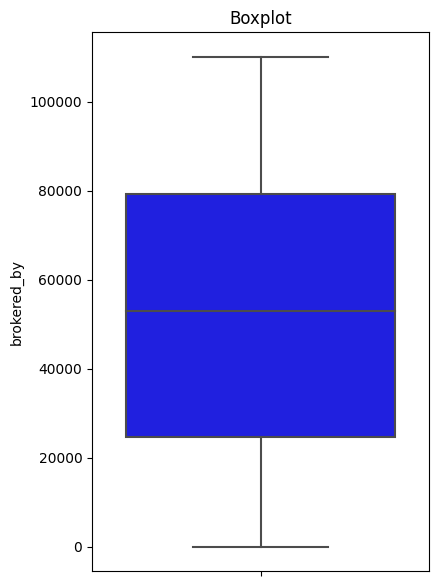

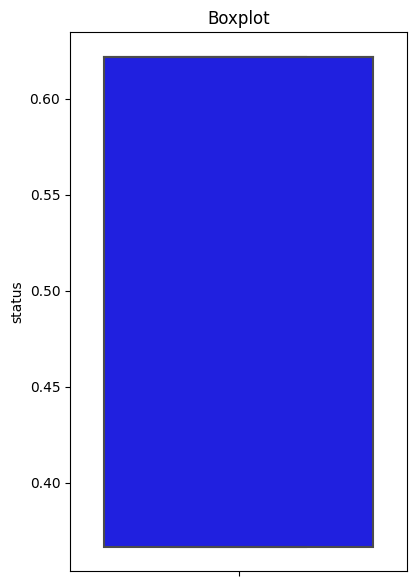

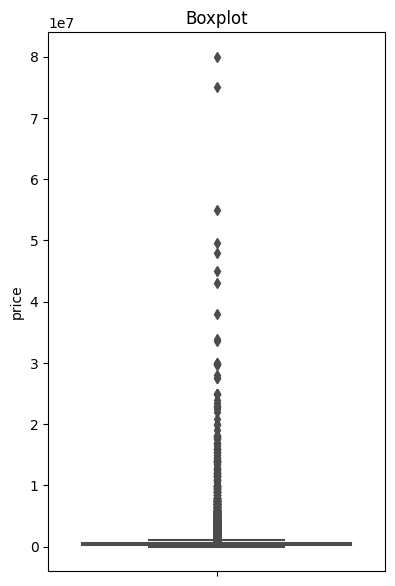

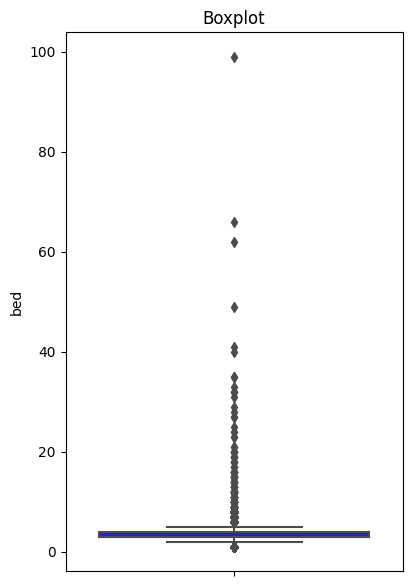

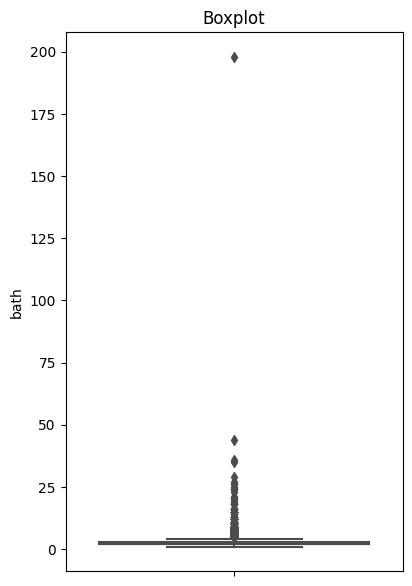

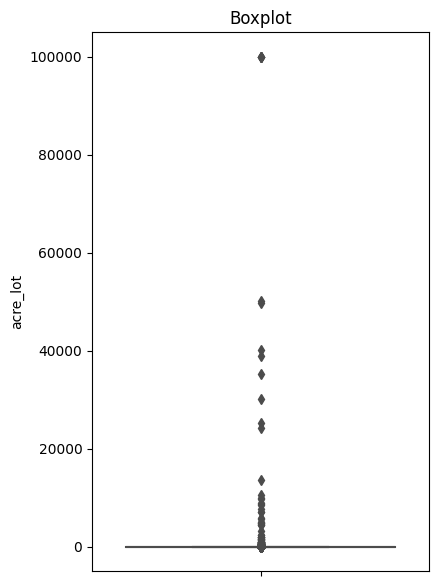

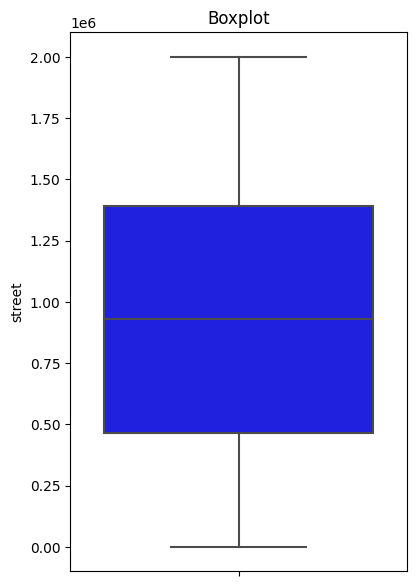

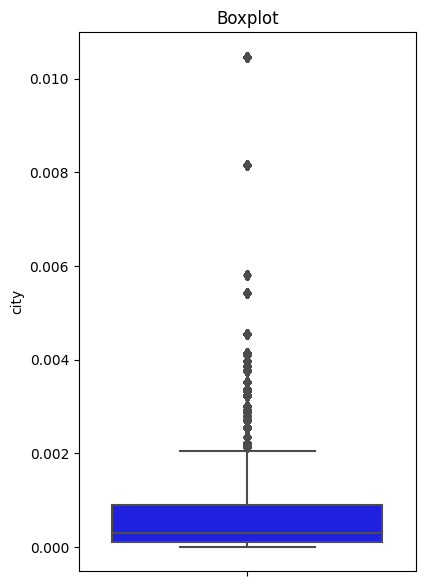

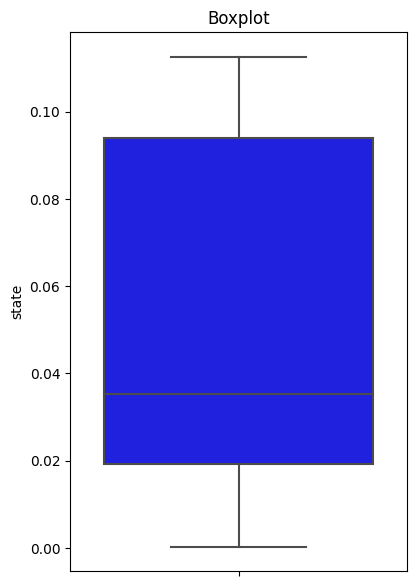

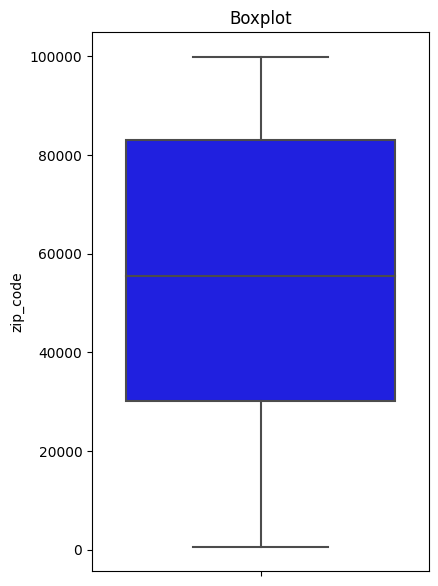

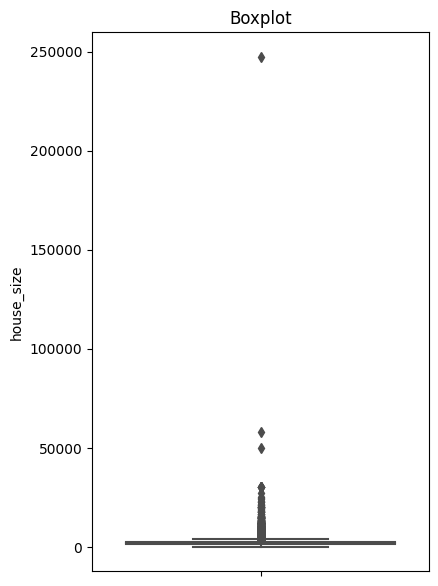

In [ ]:
for col in df:
    diagnostic_plots(df,col,'price')

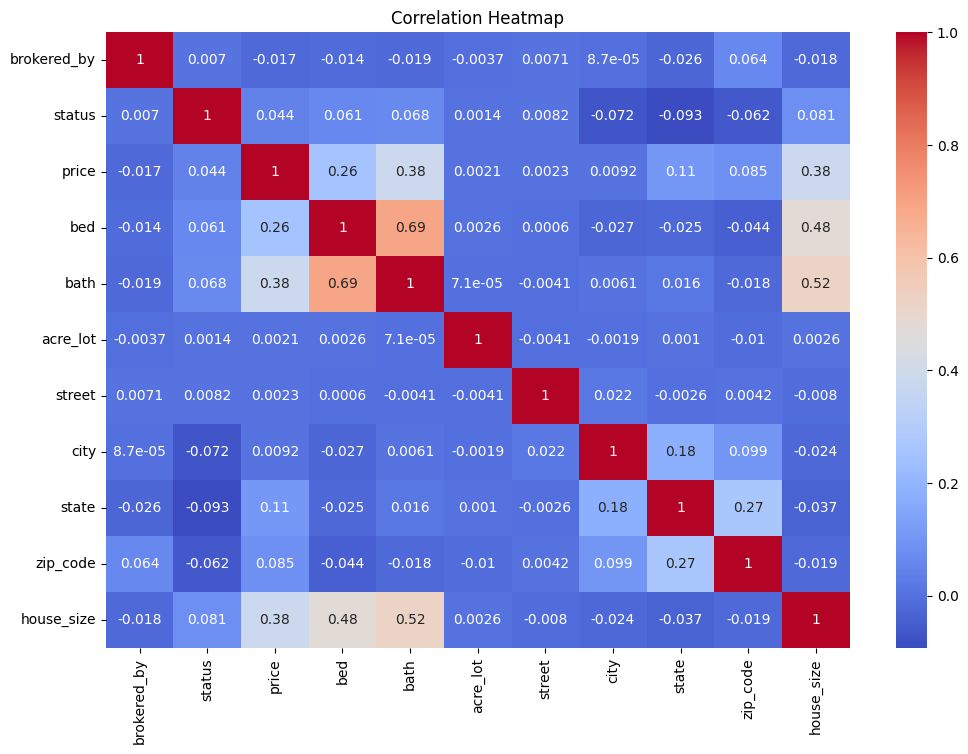

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[num].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming df is your DataFrame
X = df.drop('price', axis=1)
y = df['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the scaler, then transform both train and test data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the ANN model
model = Sequential()
model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))  # Use 'sigmoid' for classification

model.compile(optimizer='adam', loss='mean_squared_error')  # Change loss for classification

# Train the model
model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2130290409472.0000 - val_loss: 1071453634560.0000
Epoch 2/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 998445023232.0000 - val_loss: 820931592192.0000
Epoch 3/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1258963861504.0000 - val_loss: 811542708224.0000
Epoch 4/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1045141323776.0000 - val_loss: 802653011968.0000
Epoch 5/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1191187185664.0000 - val_loss: 801139392512.0000
Epoch 6/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1136227516416.0000 - val_loss: 798050549760.0000
Epoch 7/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1019664465920.0000 - val_loss: 795199930368.0000
Epoch 8/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1243644035072.0000 - val_loss: 791862181888.0000
Epoch 9/100
1213/1213 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1321269329920.0000 - val_loss: 7889410457

In [ ]:
loss = model.evaluate(X_test_scaled, y_test)
print(f'Test Loss: {loss}')

379/379 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1139110182912.0000
Test Loss: 927188582400.0
